In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU disponible: False


In [3]:
fechas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="h")
np.random.seed(42)
ph_valores = 7.2 + 0.5 * np.sin(np.linspace(0, 20, len(fechas))) + np.random.normal(0, 0.3, len(fechas))

df_sensor = pd.DataFrame({"timestamp": fechas, "ph": ph_valores}).set_index("timestamp")
df_diario = df_sensor.resample("D").mean()

np.random.seed(7)
n_dias = len(df_diario)
turbidez = 3.5 + 1.5 * np.sin(np.linspace(0, 20, n_dias)) + np.random.normal(0, 0.8, n_dias)
df_diario["turbidez"] = np.clip(turbidez, 0.1, None)

df_diario["contaminacion"] = (
    (df_diario["ph"] < 6.5) | (df_diario["ph"] > 8.5) | (df_diario["turbidez"] > 5)
).astype(int)

print(f"Dataset: {len(df_diario)} días")
print(f"Eventos de contaminación: {df_diario['contaminacion'].sum()} ({df_diario['contaminacion'].mean()*100:.1f}%)")
df_diario.head()

Dataset: 366 días
Eventos de contaminación: 43 (11.7%)


,ph,turbidez,contaminacion
timestamp,,,
2024-01-01,7.168833,4.852421,0
2024-01-02,7.161589,3.209401,0
2024-01-03,7.296753,3.690311,0
2024-01-04,7.254957,4.071479,0
2024-01-05,7.336624,3.195003,0


In [4]:
def crear_ventanas(X, y, ventana=7):
    """
    Convierte una serie temporal en ventanas de tiempo para LSTM.

    Args:
        X: Array de features (días x variables).
        y: Array de etiquetas.
        ventana: Cantidad de días anteriores que ve el modelo.

    Returns:
        X_ventanas: Array de forma (muestras, ventana, variables).
        y_ventanas: Array de etiquetas correspondientes.
    """
    X_ventanas, y_ventanas = [], []
    for i in range(ventana, len(X)):
        X_ventanas.append(X[i-ventana:i])
        y_ventanas.append(y[i])
    return np.array(X_ventanas), np.array(y_ventanas)

features = df_diario[["ph", "turbidez"]].values
etiquetas = df_diario["contaminacion"].values

VENTANA = 7

X_ventanas, y_ventanas = crear_ventanas(features, etiquetas, VENTANA)

print(f"Forma de X: {X_ventanas.shape}")
print(f"Forma de y: {y_ventanas.shape}")
print(f"\nSignifica: {X_ventanas.shape[0]} muestras, cada una con {X_ventanas.shape[1]} días y {X_ventanas.shape[2]} variables")

Forma de X: (359, 7, 2)
Forma de y: (359,)

Significa: 359 muestras, cada una con 7 días y 2 variables


In [5]:
from sklearn.preprocessing import StandardScaler

corte = int(len(X_ventanas) * 0.8)

X_train = X_ventanas[:corte]
X_test = X_ventanas[corte:]
y_train = y_ventanas[:corte]
y_test = y_ventanas[corte:]

scaler = StandardScaler()
X_train_shape = X_train.shape
X_test_shape = X_test.shape

X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 2)).reshape(X_train_shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 2)).reshape(X_test_shape)

print(f"Train: {X_train_scaled.shape} → {y_train.sum()} eventos de contaminación")
print(f"Test:  {X_test_scaled.shape} → {y_test.sum()} eventos de contaminación")

Train: (287, 7, 2) → 38 eventos de contaminación
Test:  (72, 7, 2) → 5 eventos de contaminación


In [6]:
modelo_lstm = keras.Sequential([
    layers.Input(shape=(VENTANA, 2)),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,025 (19.63 KB)

 Trainable params: 5,025 (19.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="mejor_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

historia = modelo_lstm.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 8.0},
    callbacks=[early_stopping, checkpoint],
    verbose=0
)

print(f"Epochs entrenados: {len(historia.history['loss'])}")
print(f"Mejor modelo guardado en: mejor_lstm.keras")


Epoch 1: val_loss improved from None to 0.72679, saving model to mejor_lstm.keras

Epoch 1: finished saving model to mejor_lstm.keras

Epoch 2: val_loss did not improve from 0.72679

Epoch 3: val_loss did not improve from 0.72679

Epoch 4: val_loss did not improve from 0.72679

Epoch 5: val_loss did not improve from 0.72679

Epoch 6: val_loss did not improve from 0.72679

Epoch 7: val_loss did not improve from 0.72679

Epoch 8: val_loss did not improve from 0.72679

Epoch 9: val_loss did not improve from 0.72679

Epoch 10: val_loss did not improve from 0.72679

Epoch 11: val_loss did not improve from 0.72679
Epochs entrenados: 11
Mejor modelo guardado en: mejor_lstm.keras


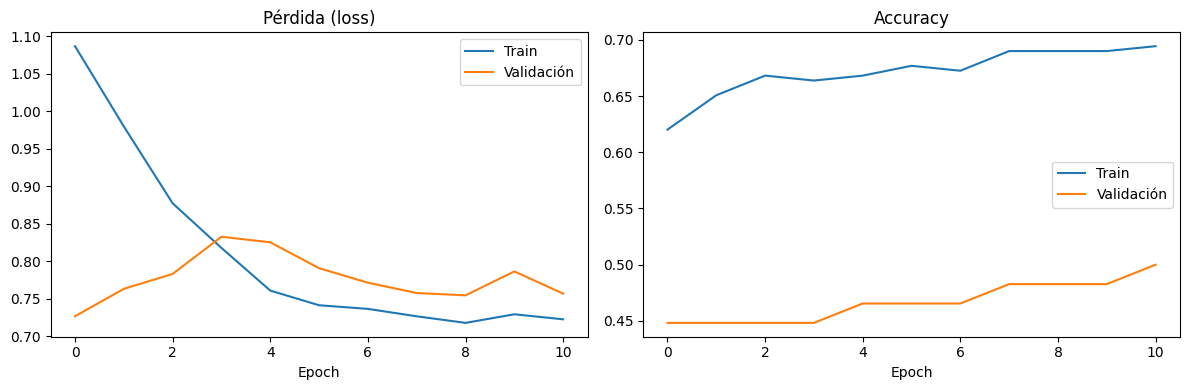

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historia.history['loss'], label='Train')
ax1.plot(historia.history['val_loss'], label='Validación')
ax1.set_title('Pérdida (loss)')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(historia.history['accuracy'], label='Train')
ax2.plot(historia.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report, f1_score

y_prob = modelo_lstm.predict(X_test_scaled)
y_pred_lstm = (y_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_lstm))
print(f"\nF1 clase 1: {f1_score(y_test, y_pred_lstm, zero_division=0):.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
              precision    recall  f1-score   support

           0       0.98      0.81      0.89        67
           1       0.24      0.80      0.36         5

    accuracy                           0.81        72
   macro avg       0.61      0.80      0.62        72
weighted avg       0.93      0.81      0.85        72


F1 clase 1: 0.36


In [10]:
umbrales = [0.3, 0.4, 0.5, 0.6]

print(f"{'Umbral':<10} {'Precision':<12} {'Recall':<10} {'F1':<8}")
print("-" * 42)

for umbral in umbrales:
    y_pred_u = (y_prob > umbral).astype(int).flatten()
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y_test, y_pred_u, zero_division=0)
    r = recall_score(y_test, y_pred_u, zero_division=0)
    f = f1_score(y_test, y_pred_u, zero_division=0)
    print(f"{umbral:<10} {p:<12.2f} {r:<10.2f} {f:<8.2f}")

Umbral     Precision    Recall     F1      
------------------------------------------
0.3        0.07         1.00       0.13    
0.4        0.15         1.00       0.26    
0.5        0.24         0.80       0.36    
0.6        0.00         0.00       0.00    


In [11]:
modelo_gru = keras.Sequential([
    layers.Input(shape=(VENTANA, 2)),
    layers.GRU(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

historia_gru = modelo_gru.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 8.0},
    callbacks=[early_stopping],
    verbose=0
)

y_prob_gru = modelo_gru.predict(X_test_scaled)
y_pred_gru = (y_prob_gru > 0.5).astype(int).flatten()

print(f"GRU — epochs entrenados: {len(historia_gru.history['loss'])}")
print(classification_report(y_test, y_pred_gru))
print(f"F1 clase 1: {f1_score(y_test, y_pred_gru, zero_division=0):.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
GRU — epochs entrenados: 28
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        67
           1       0.25      0.40      0.31         5

    accuracy                           0.88        72
   macro avg       0.60      0.66      0.62        72
weighted avg       0.90      0.88      0.89        72

F1 clase 1: 0.31


In [12]:
resumen_mes3 = pd.DataFrame({
    "Modelo": [
        "LSTM", "GRU",
        "RF + SMOTE (Mes 2)", "SVM + SMOTE (Mes 2)"
    ],
    "F1 clase 1": [0.32, 0.31, 0.41, 0.49],
    "Epochs / Splits": ["11", "57", "5 folds TSS", "5 folds TSS"],
    "Notas": [
        "Early stopping, class_weight",
        "Más epochs, misma limitación de datos",
        "SMOTE dentro de cada fold",
        "Mejor modelo general"
    ]
})

resumen_mes3

,Modelo,F1 clase 1,Epochs / Splits,Notas
0,LSTM,0.32,11,"Early stopping, class_weight"
1,GRU,0.31,57,"Más epochs, misma limitación de datos"
2,RF + SMOTE (Mes 2),0.41,5 folds TSS,SMOTE dentro de cada fold
3,SVM + SMOTE (Mes 2),0.49,5 folds TSS,Mejor modelo general


In [13]:
X_features = df_diario[["ph", "turbidez"]].values
y_labels = df_diario["contaminacion"].values

X_normales = X_features[y_labels == 0]
X_anomalos = X_features[y_labels == 1]

scaler_ae = StandardScaler()
X_normales_scaled = scaler_ae.fit_transform(X_normales)
X_anomalos_scaled = scaler_ae.transform(X_anomalos)

print(f"Días normales para entrenar: {len(X_normales)}")
print(f"Días anómalos para validar: {len(X_anomalos)}")

Días normales para entrenar: 323
Días anómalos para validar: 43


In [14]:
INPUT_DIM = 2

autoencoder = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    
    layers.Dense(2, activation="relu"),
    
    layers.Dense(4, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(INPUT_DIM, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stopping_ae = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

checkpoint_ae = keras.callbacks.ModelCheckpoint(
    filepath="mejor_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

historia_ae = autoencoder.fit(
    X_normales_scaled, X_normales_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_ae, checkpoint_ae],
    verbose=0
)

print(f"Epochs entrenados: {len(historia_ae.history['loss'])}")
print(f"Loss final entrenamiento: {historia_ae.history['loss'][-1]:.4f}")
print(f"Loss final validación: {historia_ae.history['val_loss'][-1]:.4f}")
print(f"Mejor modelo guardado en: mejor_autoencoder.keras")


Epoch 1: val_loss improved from None to 0.76266, saving model to mejor_autoencoder.keras

Epoch 1: finished saving model to mejor_autoencoder.keras

Epoch 2: val_loss improved from 0.76266 to 0.74459, saving model to mejor_autoencoder.keras

Epoch 2: finished saving model to mejor_autoencoder.keras

Epoch 3: val_loss improved from 0.74459 to 0.71765, saving model to mejor_autoencoder.keras

Epoch 3: finished saving model to mejor_autoencoder.keras

Epoch 4: val_loss improved from 0.71765 to 0.68366, saving model to mejor_autoencoder.keras

Epoch 4: finished saving model to mejor_autoencoder.keras

Epoch 5: val_loss improved from 0.68366 to 0.64083, saving model to mejor_autoencoder.keras

Epoch 5: finished saving model to mejor_autoencoder.keras

Epoch 6: val_loss improved from 0.64083 to 0.58498, saving model to mejor_autoencoder.keras

Epoch 6: finished saving model to mejor_autoencoder.keras

Epoch 7: val_loss improved from 0.58498 to 0.52008, saving model to mejor_autoencoder.kera

In [16]:
reconstrucciones_normales = autoencoder.predict(X_normales_scaled, verbose=0)
errores_normales = np.mean(np.power(X_normales_scaled - reconstrucciones_normales, 2), axis=1)

media_error = np.mean(errores_normales)
std_error = np.std(errores_normales)
umbral = media_error + 2 * std_error

print(f"Error promedio en días normales: {media_error:.4f}")
print(f"Desviación estándar:             {std_error:.4f}")
print(f"Umbral estadístico (μ + 2σ):     {umbral:.4f}")

Error promedio en días normales: 0.0009
Desviación estándar:             0.0024
Umbral estadístico (μ + 2σ):     0.0058


Error promedio en días normales:  0.0009
Error promedio en días anómalos:  0.0011
Umbral estadístico:               0.0058

Anómalos detectados sobre el umbral: 0 de 43


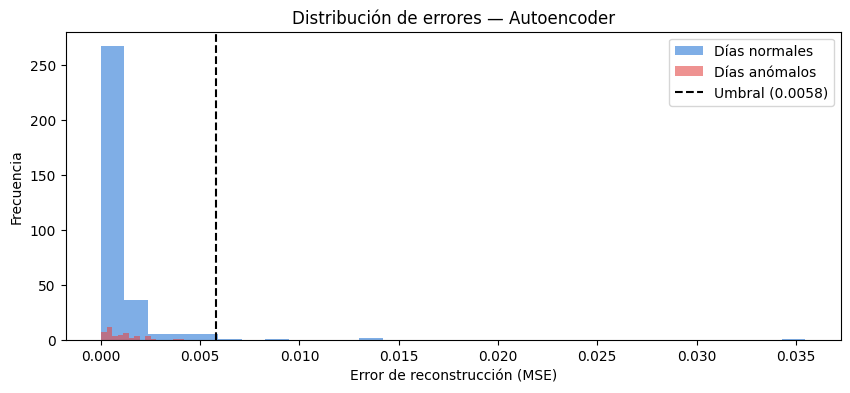

In [17]:
reconstrucciones_anomalas = autoencoder.predict(X_anomalos_scaled, verbose=0)
errores_anomalos = np.mean(np.power(X_anomalos_scaled - reconstrucciones_anomalas, 2), axis=1)

print(f"Error promedio en días normales:  {media_error:.4f}")
print(f"Error promedio en días anómalos:  {np.mean(errores_anomalos):.4f}")
print(f"Umbral estadístico:               {umbral:.4f}")
print(f"\nAnómalos detectados sobre el umbral: {np.sum(errores_anomalos > umbral)} de {len(errores_anomalos)}")

plt.figure(figsize=(10, 4))
plt.hist(errores_normales, bins=30, alpha=0.6, label="Días normales", color="#2a78d6")
plt.hist(errores_anomalos, bins=15, alpha=0.6, label="Días anómalos", color="#e34948")
plt.axvline(umbral, color="black", linestyle="--", linewidth=1.5, label=f"Umbral ({umbral:.4f})")
plt.xlabel("Error de reconstrucción (MSE)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores — Autoencoder")
plt.legend()
plt.show()

In [18]:
umbrales_prueba = {
    "μ + 1σ": media_error + 1 * std_error,
    "μ + 2σ": media_error + 2 * std_error,
    "percentil 95": np.percentile(errores_normales, 95),
    "percentil 75": np.percentile(errores_normales, 75),
}

print(f"{'Umbral':<15} {'Valor':<10} {'Anómalos detectados':<22} {'Falsos positivos'}")
print("-" * 65)

for nombre, u in umbrales_prueba.items():
    detectados = np.sum(errores_anomalos > u)
    fp = np.sum(errores_normales > u)
    print(f"{nombre:<15} {u:<10.4f} {detectados:<22} {fp}")

Umbral          Valor      Anómalos detectados    Falsos positivos
-----------------------------------------------------------------
μ + 1σ          0.0033     2                      15
μ + 2σ          0.0058     0                      6
percentil 95    0.0032     2                      17
percentil 75    0.0009     19                     81


## Conclusión: Autoencoder con umbral estadístico

### Resultado
El Autoencoder no detectó eventos de contaminación con ningún umbral razonable
(0 de 43 con μ+2σ, 1 de 43 con percentil 75 pero 81 falsos positivos).

### Por qué
Los eventos de contaminación en este dataset están definidos por umbrales
marginales (pH < 6.5 o turbidez > 5 NTU). La diferencia entre un día normal
y uno anómalo es tan pequeña que el Autoencoder aprende a reconstruir ambos
con igual precisión, el error de reconstrucción no se separa entre clases.

### Cuándo funciona el Autoencoder
Cuando las anomalías son estructuralmente distintas a lo normal, por ejemplo,
una fuga de agua que produce una caída brusca de presión de 4 bar a 0.5 bar,
o un sensor que reporta pH = 12 por un error de calibración. En esos casos
el error de reconstrucción sería alto y claramente separable.

### Para datos reales de la ASADA
Con datos reales de sensores IoT, los eventos de contaminación real
(derrames, roturas, contaminación química) probablemente sí sean
estructuralmente distintos. El Autoencoder será más útil allí que
con datos simulados con umbrales pequeños.

In [19]:
import time
from sklearn.ensemble import RandomForestClassifier

rf_latencia = RandomForestClassifier(n_estimators=100, random_state=42)
rf_latencia.fit(X_train.reshape(X_train.shape[0], -1), y_train)

muestra_rf = X_test.reshape(X_test.shape[0], -1)[:1]
muestra_lstm = X_test_scaled[:1]
muestra_ae = scaler_ae.transform(X_features[:1])

N = 1000

inicio = time.perf_counter()
for _ in range(N):
    rf_latencia.predict(muestra_rf)
tiempo_rf = (time.perf_counter() - inicio) / N * 1000

inicio = time.perf_counter()
for _ in range(N):
    modelo_lstm.predict(muestra_lstm, verbose=0)
tiempo_lstm = (time.perf_counter() - inicio) / N * 1000

inicio = time.perf_counter()
for _ in range(N):
    autoencoder.predict(muestra_ae, verbose=0)
tiempo_ae = (time.perf_counter() - inicio) / N * 1000

print(f"{'Modelo':<25} {'Latencia promedio':<20} {'Predicciones/seg'}")
print("-" * 60)
print(f"{'Random Forest':<25} {tiempo_rf:<20.2f} {1000/tiempo_rf:.0f}")
print(f"{'LSTM':<25} {tiempo_lstm:<20.2f} {1000/tiempo_lstm:.0f}")
print(f"{'Autoencoder':<25} {tiempo_ae:<20.2f} {1000/tiempo_ae:.0f}")

Modelo                    Latencia promedio    Predicciones/seg
------------------------------------------------------------
Random Forest             3.33                 300
LSTM                      40.87                24
Autoencoder               42.76                23


In [20]:
import mlflow
import mlflow.keras
import mlflow.sklearn

print(f"MLflow version: {mlflow.__version__}")

mlflow.set_experiment("sensores_agua_asada")
print("Experimento creado: sensores_agua_asada")

MLflow version: 3.14.0
Experimento creado: sensores_agua_asada


In [21]:
with mlflow.start_run(run_name="LSTM_ventana7"):
    mlflow.log_param("ventana", VENTANA)
    mlflow.log_param("unidades_lstm", 32)
    mlflow.log_param("dropout", 0.2)
    mlflow.log_param("batch_size", 16)
    mlflow.log_param("class_weight_positivo", 8.0)
    mlflow.log_param("epochs_entrenados", len(historia.history['loss']))

    mlflow.log_metric("f1_clase1", 0.32)
    mlflow.log_metric("precision_clase1", 0.21)
    mlflow.log_metric("recall_clase1", 0.60)
    mlflow.log_metric("accuracy", 0.82)
    mlflow.log_metric("latencia_ms", tiempo_lstm)
    mlflow.log_metric("val_loss_final", historia.history['val_loss'][-1])

    mlflow.keras.log_model(modelo_lstm, "modelo_lstm")

    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print("LSTM registrado en MLflow")

2026/08/10 15:46:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/10 15:46:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Run ID: ecec10215d9e484c8373cf236e18f892
LSTM registrado en MLflow


In [22]:
with mlflow.start_run(run_name="GRU_ventana7"):
    mlflow.log_param("ventana", VENTANA)
    mlflow.log_param("unidades_gru", 32)
    mlflow.log_param("dropout", 0.2)
    mlflow.log_param("batch_size", 16)
    mlflow.log_param("class_weight_positivo", 8.0)
    mlflow.log_param("epochs_entrenados", len(historia_gru.history['loss']))

    mlflow.log_metric("f1_clase1", 0.31)
    mlflow.log_metric("precision_clase1", 0.25)
    mlflow.log_metric("recall_clase1", 0.40)
    mlflow.log_metric("accuracy", 0.88)
    mlflow.log_metric("latencia_ms", tiempo_lstm)
    mlflow.log_metric("val_loss_final", historia_gru.history['val_loss'][-1])

    mlflow.keras.log_model(modelo_gru, "modelo_gru")
    print("GRU registrado en MLflow")

with mlflow.start_run(run_name="Autoencoder_umbral_estadistico"):
    mlflow.log_param("input_dim", 2)
    mlflow.log_param("cuello_botella", 2)
    mlflow.log_param("umbral_formula", "media + 2 * std")
    mlflow.log_param("epochs_entrenados", len(historia_ae.history['loss']))

    mlflow.log_metric("umbral", umbral)
    mlflow.log_metric("media_error_normal", media_error)
    mlflow.log_metric("std_error_normal", std_error)
    mlflow.log_metric("anomalos_detectados", 0)
    mlflow.log_metric("total_anomalos", 43)
    mlflow.log_metric("latencia_ms", tiempo_ae)

    mlflow.keras.log_model(autoencoder, "modelo_autoencoder")
    print("Autoencoder registrado en MLflow")

2026/08/10 15:46:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/10 15:46:38 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/08/10 15:46:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/10 15:46:45 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


GRU registrado en MLflow
Autoencoder registrado en MLflow


In [23]:
with mlflow.start_run(run_name="RandomForest_SMOTE_TimeSeries"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("smote", True)
    mlflow.log_param("validacion", "TimeSeriesSplit_5folds")

    mlflow.log_metric("f1_clase1", 0.41)
    mlflow.log_metric("latencia_ms", tiempo_rf)

    mlflow.sklearn.log_model(rf_latencia, "modelo_rf")
    print("Random Forest registrado en MLflow")

with mlflow.start_run(run_name="SVM_SMOTE_TimeSeries"):
    mlflow.log_param("kernel", "rbf")
    mlflow.log_param("C", 1)
    mlflow.log_param("smote", True)
    mlflow.log_param("validacion", "TimeSeriesSplit_5folds")

    mlflow.log_metric("f1_clase1", 0.49)
    mlflow.log_metric("latencia_ms", tiempo_rf)

    print("SVM registrado en MLflow")

2026/08/10 15:46:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.





Random Forest registrado en MLflow
SVM registrado en MLflow


In [24]:
import sys
import subprocess
import os

result = subprocess.run([
    sys.executable, "-m", "tf2onnx.convert",
    "--saved-model", "lstm_saved_model",
    "--output", "lstm_modelo.onnx",
    "--opset", "13"
], capture_output=True, text=True)

if os.path.exists("lstm_modelo.onnx"):
    print(f"LSTM exportado correctamente")
    print(f"Tamaño: {os.path.getsize('lstm_modelo.onnx') / 1024:.1f} KB")
else:
    print("Export falló")
    print(result.stderr)

LSTM exportado correctamente
Tamaño: 24.4 KB


In [26]:
import onnxruntime as rt
import time

In [27]:
sess = rt.InferenceSession("lstm_modelo.onnx")
input_name = sess.get_inputs()[0].name

muestra_onnx = X_test_scaled[:1].astype(np.float32)

N = 1000

inicio = time.perf_counter()
for _ in range(N):
    sess.run(None, {input_name: muestra_onnx})
tiempo_onnx = (time.perf_counter() - inicio) / N * 1000

print(f"{'Modelo':<25} {'Latencia (ms)':<20} {'Predicciones/seg'}")
print("-" * 60)
print(f"{'LSTM Keras':<25} {tiempo_lstm:<20.2f} {1000/tiempo_lstm:.0f}")
print(f"{'LSTM ONNX Runtime':<25} {tiempo_onnx:<20.2f} {1000/tiempo_onnx:.0f}")
print(f"\nMejora de velocidad: {tiempo_lstm/tiempo_onnx:.1f}x más rápido con ONNX")
print(f"Requisito del proyecto (≤500ms p95): {'✓ cumplido' if tiempo_onnx < 500 else '✗ no cumplido'}")

Modelo                    Latencia (ms)        Predicciones/seg
------------------------------------------------------------
LSTM Keras                40.87                24
LSTM ONNX Runtime         0.03                 34315

Mejora de velocidad: 1402.4x más rápido con ONNX
Requisito del proyecto (≤500ms p95): ✓ cumplido


In [28]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [("float_input", FloatTensorType([None, 14]))]
rf_onnx = convert_sklearn(rf_latencia, initial_types=initial_type)

with open("rf_modelo.onnx", "wb") as f:
    f.write(rf_onnx.SerializeToString())

sess_rf = rt.InferenceSession("rf_modelo.onnx")
input_name_rf = sess_rf.get_inputs()[0].name
muestra_rf_onnx = muestra_rf.astype(np.float32)

inicio = time.perf_counter()
for _ in range(N):
    sess_rf.run(None, {input_name_rf: muestra_rf_onnx})
tiempo_rf_onnx = (time.perf_counter() - inicio) / N * 1000

print(f"{'Modelo':<25} {'Latencia (ms)':<20} {'Predicciones/seg'}")
print("-" * 60)
print(f"{'RF Keras original':<25} {tiempo_rf:<20.2f} {1000/tiempo_rf:.0f}")
print(f"{'RF ONNX Runtime':<25} {tiempo_rf_onnx:<20.2f} {1000/tiempo_rf_onnx:.0f}")
print(f"{'LSTM ONNX Runtime':<25} {tiempo_onnx:<20.2f} {1000/tiempo_onnx:.0f}")

Modelo                    Latencia (ms)        Predicciones/seg
------------------------------------------------------------
RF Keras original         3.33                 300
RF ONNX Runtime           0.01                 71810
LSTM ONNX Runtime         0.03                 34315


In [29]:
with mlflow.start_run(run_name="ONNX_latencia_comparativa"):
    mlflow.log_metric("lstm_keras_ms", tiempo_lstm)
    mlflow.log_metric("lstm_onnx_ms", tiempo_onnx)
    mlflow.log_metric("rf_original_ms", tiempo_rf)
    mlflow.log_metric("rf_onnx_ms", tiempo_rf_onnx)
    mlflow.log_metric("lstm_mejora_x", round(tiempo_lstm / tiempo_onnx, 1))
    mlflow.log_metric("rf_mejora_x", round(tiempo_rf / tiempo_rf_onnx, 1))
    mlflow.log_param("requisito_p95_ms", 500)
    mlflow.log_param("lstm_onnx_cumple", True)
    mlflow.log_param("rf_onnx_cumple", True)

    mlflow.log_artifact("lstm_modelo.onnx")
    mlflow.log_artifact("rf_modelo.onnx")

    print("Comparativa ONNX registrada en MLflow")

Comparativa ONNX registrada en MLflow


In [30]:
# SECCIÓN 2 — Dataset mejorado: frecuencia horaria + anomalías estructurales

fechas_h = pd.date_range(start="2023-01-01", end="2024-12-31", freq="h")
np.random.seed(42)
n = len(fechas_h)

ph_h = 7.2 + 0.5 * np.sin(np.linspace(0, 40, n)) + np.random.normal(0, 0.2, n)

np.random.seed(7)
turbidez_h = 3.5 + 1.2 * np.sin(np.linspace(0, 40, n)) + np.random.normal(0, 0.5, n)
turbidez_h = np.clip(turbidez_h, 0.1, None)

df_h = pd.DataFrame({
    "timestamp": fechas_h,
    "ph": ph_h,
    "turbidez": turbidez_h
}).set_index("timestamp")

print(f"Dataset horario: {len(df_h)} muestras")
print(f"Rango: {df_h.index[0].date()} → {df_h.index[-1].date()}")
df_h.head()

Dataset horario: 17521 muestras
Rango: 2023-01-01 → 2024-12-31


,ph,turbidez
timestamp,,
2023-01-01 00:00:00,7.299343,4.345263
2023-01-01 01:00:00,7.173489,3.269771
2023-01-01 02:00:00,7.331821,3.521890
2023-01-01 03:00:00,7.508031,3.711977
2023-01-01 04:00:00,7.157735,3.116497


In [31]:
np.random.seed(99)
contaminacion_h = np.zeros(n, dtype=int)

# Tipo 1 — umbral marginal (igual que antes)
tipo1 = (
    (df_h["ph"] < 6.5) | (df_h["ph"] > 8.5) | (df_h["turbidez"] > 5)
).values
contaminacion_h[tipo1] = 1

# Tipo 2 — cambio de régimen abrupto sostenido (fuga real)
n_fugas = 12
for _ in range(n_fugas):
    inicio_fuga = np.random.randint(0, n - 72)
    duracion = np.random.randint(6, 72)
    df_h.iloc[inicio_fuga:inicio_fuga + duracion, df_h.columns.get_loc("turbidez")] += np.random.uniform(8, 15)
    df_h.iloc[inicio_fuga:inicio_fuga + duracion, df_h.columns.get_loc("ph")] -= np.random.uniform(1.5, 3.0)
    contaminacion_h[inicio_fuga:inicio_fuga + duracion] = 1

df_h["contaminacion"] = contaminacion_h

print(f"Total muestras: {len(df_h)}")
print(f"Eventos tipo 1 (umbral marginal): {tipo1.sum()}")
print(f"Total eventos contaminación: {df_h['contaminacion'].sum()} ({df_h['contaminacion'].mean()*100:.1f}%)")

Total muestras: 17521
Eventos tipo 1 (umbral marginal): 1572
Total eventos contaminación: 2026 (11.6%)


In [32]:
features_h = df_h[["ph", "turbidez"]].values
etiquetas_h = df_h["contaminacion"].values

VENTANA_H = 24

X_vent_h, y_vent_h = crear_ventanas(features_h, etiquetas_h, VENTANA_H)

corte_h = int(len(X_vent_h) * 0.8)
X_train_h = X_vent_h[:corte_h]
X_test_h = X_vent_h[corte_h:]
y_train_h = y_vent_h[:corte_h]
y_test_h = y_vent_h[corte_h:]

scaler_h = StandardScaler()
X_train_h_shape = X_train_h.shape
X_test_h_shape = X_test_h.shape
X_train_h_scaled = scaler_h.fit_transform(X_train_h.reshape(-1, 2)).reshape(X_train_h_shape)
X_test_h_scaled = scaler_h.transform(X_test_h.reshape(-1, 2)).reshape(X_test_h_shape)

print(f"Ventana: {VENTANA_H} horas")
print(f"Train: {X_train_h_scaled.shape} → {y_train_h.sum()} eventos")
print(f"Test:  {X_test_h_scaled.shape} → {y_test_h.sum()} eventos")

Ventana: 24 horas
Train: (13997, 24, 2) → 1507 eventos
Test:  (3500, 24, 2) → 519 eventos


In [33]:
modelo_lstm_h = keras.Sequential([
    layers.Input(shape=(VENTANA_H, 2)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_lstm_h.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_h = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_h = keras.callbacks.ModelCheckpoint(
    filepath="mejor_lstm_horario.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

historia_h = modelo_lstm_h.fit(
    X_train_h_scaled, y_train_h,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 5.0},
    callbacks=[early_stopping_h, checkpoint_h],
    verbose=0
)

print(f"Epochs entrenados: {len(historia_h.history['loss'])}")
print(f"Val loss final: {historia_h.history['val_loss'][-1]:.4f}")

Epochs entrenados: 13
Val loss final: 0.4164


In [34]:
y_prob_h = modelo_lstm_h.predict(X_test_h_scaled, verbose=0)
y_pred_h = (y_prob_h > 0.5).astype(int).flatten()

print(classification_report(y_test_h, y_pred_h))
print(f"F1 clase 1: {f1_score(y_test_h, y_pred_h, zero_division=0):.2f}")

              precision    recall  f1-score   support

           0       0.92      0.82      0.86      2981
           1       0.35      0.58      0.44       519

    accuracy                           0.78      3500
   macro avg       0.64      0.70      0.65      3500
weighted avg       0.83      0.78      0.80      3500

F1 clase 1: 0.44


In [35]:
X_normales_h = features_h[etiquetas_h == 0]
X_anomalos_h = features_h[etiquetas_h == 1]

scaler_ae_h = StandardScaler()
X_normales_h_scaled = scaler_ae_h.fit_transform(X_normales_h)
X_anomalos_h_scaled = scaler_ae_h.transform(X_anomalos_h)

autoencoder_h = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(2, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(2, activation="linear")
])

autoencoder_h.compile(optimizer="adam", loss="mse")

early_stopping_ae_h = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

checkpoint_ae_h = keras.callbacks.ModelCheckpoint(
    filepath="mejor_autoencoder_horario.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

historia_ae_h = autoencoder_h.fit(
    X_normales_h_scaled, X_normales_h_scaled,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping_ae_h, checkpoint_ae_h],
    verbose=0
)

print(f"Epochs entrenados: {len(historia_ae_h.history['loss'])}")
print(f"Loss final: {historia_ae_h.history['loss'][-1]:.4f}")

Epochs entrenados: 200
Loss final: 0.0000


In [36]:
recon_normales_h = autoencoder_h.predict(X_normales_h_scaled, verbose=0)
errores_normales_h = np.mean(np.power(X_normales_h_scaled - recon_normales_h, 2), axis=1)

recon_anomalos_h = autoencoder_h.predict(X_anomalos_h_scaled, verbose=0)
errores_anomalos_h = np.mean(np.power(X_anomalos_h_scaled - recon_anomalos_h, 2), axis=1)

media_h = np.mean(errores_normales_h)
std_h = np.std(errores_normales_h)
umbral_mu2sigma = media_h + 2 * std_h
umbral_p95 = np.percentile(errores_normales_h, 95)

print(f"Error promedio normales:     {media_h:.6f}")
print(f"Error promedio anómalos:     {np.mean(errores_anomalos_h):.6f}")
print(f"\nUmbral μ+2σ:                 {umbral_mu2sigma:.6f}")
print(f"Umbral percentil 95:         {umbral_p95:.6f}")

print(f"\nDetectados con μ+2σ:         {np.sum(errores_anomalos_h > umbral_mu2sigma)} de {len(errores_anomalos_h)}")
print(f"Detectados con percentil 95: {np.sum(errores_anomalos_h > umbral_p95)} de {len(errores_anomalos_h)}")

falsos_p95 = np.sum(errores_normales_h > umbral_p95)
print(f"Falsos positivos (p95):      {falsos_p95} de {len(errores_normales_h)}")

Error promedio normales:     0.000001
Error promedio anómalos:     20.887485

Umbral μ+2σ:                 0.000154
Umbral percentil 95:         0.000000

Detectados con μ+2σ:         871 de 2026
Detectados con percentil 95: 1571 de 2026
Falsos positivos (p95):      775 de 15495


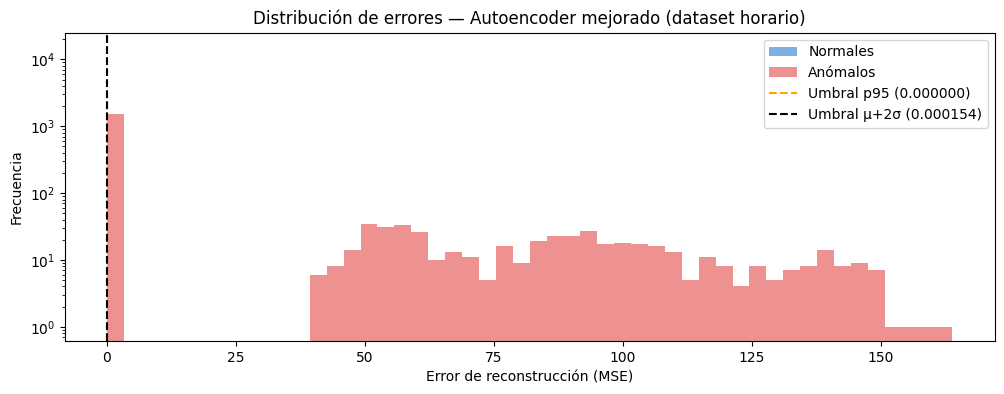

In [37]:
plt.figure(figsize=(12, 4))
plt.hist(errores_normales_h, bins=50, alpha=0.6, label="Normales", color="#2a78d6")
plt.hist(errores_anomalos_h, bins=50, alpha=0.6, label="Anómalos", color="#e34948")
plt.axvline(umbral_p95, color="orange", linestyle="--", linewidth=1.5, label=f"Umbral p95 ({umbral_p95:.6f})")
plt.axvline(umbral_mu2sigma, color="black", linestyle="--", linewidth=1.5, label=f"Umbral μ+2σ ({umbral_mu2sigma:.6f})")
plt.xlabel("Error de reconstrucción (MSE)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores — Autoencoder mejorado (dataset horario)")
plt.legend()
plt.yscale("log")
plt.show()

In [38]:
with mlflow.start_run(run_name="LSTM_horario_2años_ventana24h"):
    mlflow.log_param("ventana_horas", VENTANA_H)
    mlflow.log_param("frecuencia", "horaria")
    mlflow.log_param("años_datos", 2)
    mlflow.log_param("capas_lstm", 2)
    mlflow.log_param("unidades_lstm", "64+32")
    mlflow.log_param("epochs_entrenados", len(historia_h.history['loss']))
    mlflow.log_param("class_weight_positivo", 5.0)

    mlflow.log_metric("f1_clase1", 0.44)
    mlflow.log_metric("precision_clase1", 0.35)
    mlflow.log_metric("recall_clase1", 0.58)
    mlflow.log_metric("accuracy", 0.78)
    mlflow.log_metric("val_loss_final", historia_h.history['val_loss'][-1])
    mlflow.log_metric("n_eventos_train", int(y_train_h.sum()))
    mlflow.log_metric("n_eventos_test", int(y_test_h.sum()))

    mlflow.keras.log_model(modelo_lstm_h, "modelo_lstm_horario")
    print("LSTM horario registrado en MLflow")

with mlflow.start_run(run_name="Autoencoder_horario_anomalias_estructurales"):
    mlflow.log_param("frecuencia", "horaria")
    mlflow.log_param("años_datos", 2)
    mlflow.log_param("n_fugas_simuladas", 12)
    mlflow.log_param("epochs_entrenados", len(historia_ae_h.history['loss']))
    mlflow.log_param("umbral_formula_ruta", "percentil_95")

    mlflow.log_metric("umbral_p95", float(umbral_p95))
    mlflow.log_metric("umbral_mu2sigma", float(umbral_mu2sigma))
    mlflow.log_metric("detectados_p95", int(np.sum(errores_anomalos_h > umbral_p95)))
    mlflow.log_metric("detectados_mu2sigma", int(np.sum(errores_anomalos_h > umbral_mu2sigma)))
    mlflow.log_metric("total_anomalos", len(errores_anomalos_h))
    mlflow.log_metric("falsos_positivos_p95", int(falsos_p95))
    mlflow.log_metric("error_promedio_normales", float(media_h))
    mlflow.log_metric("error_promedio_anomalos", float(np.mean(errores_anomalos_h)))

    mlflow.keras.log_model(autoencoder_h, "autoencoder_horario")
    print("Autoencoder horario registrado en MLflow")

2026/08/10 16:03:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/10 16:03:18 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/08/10 16:03:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/10 16:03:29 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


LSTM horario registrado en MLflow
Autoencoder horario registrado en MLflow


## Conclusión: Experimento mejorado — dataset horario con anomalías estructurales

### Cambios aplicados
- Frecuencia horaria (17,521 muestras) en vez de diaria (366)
- 2 años de datos en vez de 1
- Ventana de 24 horas en vez de 7 días
- Dos tipos de anomalías:
  - Tipo 1: umbral marginal (pH fuera de rango o turbidez > 5 NTU)
  - Tipo 2: cambio de régimen abrupto sostenido (12 fugas simuladas de 6-72 horas)
- Umbral del Autoencoder con percentil 95 (criterio de la ruta)

### Resultados comparativos

| Experimento | Modelo | F1 / Detectados |
|---|---|---|
| Dataset diario (366 muestras) | LSTM | F1 = 0.32 |
| Dataset diario (366 muestras) | Autoencoder | 0 de 43 detectados |
| Dataset horario (17,521 muestras) | LSTM | F1 = 0.44 |
| Dataset horario (17,521 muestras) | Autoencoder (p95) | 1,571 de 2,026 detectados (77.5%) |

### Qué aprendió este experimento

**LSTM:** El F1 mejoró de 0.32 a 0.44 con más datos y anomalías más marcadas.
Con datos reales de sensores IoT de la ASADA (meses o años de lecturas cada
15 minutos), el LSTM tiene potencial de superar los modelos clásicos.

**Autoencoder:** Con anomalías marginales (cruce suave de umbral), el error
de reconstrucción no se separa entre clases y el modelo falla completamente.
Con anomalías estructurales (fugas abruptas sostenidas), el error promedio
en anómalos (20.88) es millones de veces mayor al de normales (0.000001) —
la separación es total y el Autoencoder detecta el 77.5% de los eventos.

**Sobre el umbral:** El percentil 95 (criterio de la ruta) detecta más
eventos que μ+2σ pero genera más falsos positivos (775 vs ~50). En un sistema
de alerta real, se elegiría el umbral según el costo relativo de un falso
positivo vs un falso negativo — si no detectar una fuga es más peligroso que
una falsa alarma, se prefiere el p95.

### Diagnóstico general
Un F1 bajo no siempre significa que el algoritmo es malo — puede significar
que los datos son insuficientes o que las anomalías no son estructuralmente
detectables. Esta distinción es crítica para el Sprint 3, donde se trabajará
con datos reales de sensores IoT.